# Occupation Signals at Polity Collapse

We identify occupations whose share among notable individuals rises or falls systematically in the decades preceding regime termination. For each occupation we compare its share in the 25 years before collapse (t−25 to t) with the preceding 25 years (t−50 to t−25) across all terminated polities in the Cultura database.

1. **Data loading** — fetch all terminated polities and their collapse dates from the database.
2. **Wilcoxon signed-rank test** — screen occupations for systematic pre-collapse share changes.
3. **Difference-in-differences** — subtract background trends from non-collapsed polities.
4. **Visualisation** — plot the top signal (collapsed vs. non-collapsed background).

In [1]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.sqlite3"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## 1. Data Loading

Terminated polities are identified automatically from `cliopatria_polity_periods` (max end year < 2020). Polities with duration ≥ 150 years are classified as long-lived (25-year bins); the rest as short-lived (10-year bins). We require at least 200 individuals in the 50-year pre-collapse window for a polity to enter the analysis, and at least 10 individuals with a given occupation across the whole polity for that occupation to be tested.

In [2]:
import sqlite3, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter, defaultdict
from scipy.stats import wilcoxon

DB = DB_PATH
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

# ── Fetch all terminated polities from the DB ──
# For each polity_name in consolidated_database, get its end year from polities_periods_cliopatria
polity_meta = {}  # polity_name -> (start, end, n_total)
for pname, pid_str, n in conn.execute('''
    SELECT polity_name, polity_id, COUNT(*) as n
    FROM consolidated_database
    WHERE floruit_year IS NOT NULL AND occupations IS NOT NULL
    GROUP BY polity_name, polity_id
'''):
    # Use last polity_id component for date lookup
    last_pid = int(pid_str.split(';')[-1])
    row = conn.execute(
        'SELECT MIN(from_year), MAX(to_year) FROM polities_periods_cliopatria WHERE polity_id=?',
        (last_pid,)).fetchone()
    if row and row[0] is not None and row[1] is not None and row[1] < 2020:
        polity_meta[pname] = (row[0], row[1], n)

# ── Build polity list: require >=200 individuals in 50yr pre-collapse window ──
DURATION_THRESHOLD = 150  # years: long-lived if >= 150
MIN_WINDOW_N = 200

polities = []  # (polity_name, collapse_yr, duration, ptype, n_window)
for pname, (start, end, n_total) in polity_meta.items():
    duration = end - start
    # Count individuals in 50yr pre-collapse window
    n_window = conn.execute('''
        SELECT COUNT(*) FROM consolidated_database
        WHERE polity_name = ? AND floruit_year IS NOT NULL AND occupations IS NOT NULL
          AND floruit_year >= ? AND floruit_year <= ?
    ''', (pname, end - 50, end)).fetchone()[0]
    if n_window >= MIN_WINDOW_N:
        ptype = 'long' if duration >= DURATION_THRESHOLD else 'short'
        polities.append((pname, end, duration, ptype, n_window))

polities.sort(key=lambda x: -x[4])  # sort by window size

n_short = sum(1 for p in polities if p[3] == 'short')
n_long  = sum(1 for p in polities if p[3] == 'long')
print(f'Terminated polities with >=200 indiv in 50yr window: {len(polities)}')
print(f'  Short-lived (<{DURATION_THRESHOLD}yr): {n_short}')
print(f'  Long-lived (>={DURATION_THRESHOLD}yr): {n_long}')

# ── Load 50-year pre-collapse windows ──
polity_data = {}  # polity_name -> [(year, [occs])]
occ_per_polity = defaultdict(Counter)  # polity_name -> Counter(occ -> count)

for pname, collapse_yr, dur, ptype, nw in polities:
    rows = conn.execute('''
        SELECT floruit_year, occupations FROM consolidated_database
        WHERE polity_name = ? AND floruit_year IS NOT NULL AND occupations IS NOT NULL
          AND floruit_year >= ? AND floruit_year <= ?
    ''', (pname, collapse_yr - 50, collapse_yr)).fetchall()
    parsed = []
    for year, occs_str in rows:
        occs = [o.strip() for o in occs_str.split('; ') if o.strip()]
        parsed.append((year, occs))
        for o in occs:
            occ_per_polity[pname][o] += 1
    polity_data[pname] = parsed

conn.close()

# ── Show polity summary ──
print(f'\nPolity summary (top 30 by window size):')
for pname, cy, dur, pt, nw in polities[:30]:
    label = pname[:55]
    print(f'  {label:55s}  end={cy:5d}  dur={dur:4d}yr  type={pt:5s}  N_window={nw:>6,}')
if len(polities) > 30:
    print(f'  ... and {len(polities)-30} more')


Terminated polities with >=200 indiv in 50yr window: 97
  Short-lived (<150yr): 88
  Long-lived (>=150yr): 9



Polity summary (top 30 by window size):
  French Fifth Republic                                    end= 1989  dur=  28yr  type=short  N_window=72,611
  United States of America;(United States of America)      end= 1897  dur= 105yr  type=short  N_window=51,741
  German Democratic Republic                               end= 1972  dur=  14yr  type=short  N_window=42,112
  Austria-Hungary                                          end= 1907  dur=  22yr  type=short  N_window=34,955
  Nazi Germany                                             end= 1991  dur=  45yr  type=short  N_window=33,146
  (British Empire);Kingdom of Great Britain                end= 1889  dur= 180yr  type=long   N_window=29,469
  German Empire                                            end= 1897  dur=   2yr  type=short  N_window=26,409
  Czechoslovakia                                           end= 1991  dur=  69yr  type=short  N_window=24,089
  Weimar Republic                                          end= 1931  dur=   3y

## 2. Wilcoxon Signed-Rank Test

For each occupation, compute the change in share between the early half (t−50 to t−26) and the late half (t−25 to t) of the pre-collapse window across all polities where the occupation has ≥10 individuals. Test with Wilcoxon signed-rank + Benjamini–Hochberg correction.

In [3]:
def bh_correction(pvalues):
    n = len(pvalues)
    pv = np.array(pvalues, dtype=float)
    order = np.argsort(pv)
    sorted_pv = pv[order]
    adjusted = np.empty(n)
    adjusted[n - 1] = sorted_pv[n - 1]
    for i in range(n - 2, -1, -1):
        adjusted[i] = min(sorted_pv[i] * n / (i + 1), adjusted[i + 1])
    adjusted = np.minimum(adjusted, 1.0)
    result = np.empty(n)
    result[order] = adjusted
    return result

# Collect all occupations that appear with >=10 individuals in at least one polity
candidate_occs = set()
for pname in occ_per_polity:
    for occ, cnt in occ_per_polity[pname].items():
        if cnt >= 10:
            candidate_occs.add(occ)
# Exclude "researcher" (too generic)
candidate_occs.discard('researcher')
print(f'Candidate occupations (>=10 in at least one polity): {len(candidate_occs)}')

MIN_POLITIES = 8  # need at least 8 polities for Wilcoxon

results = []
for occ in candidate_occs:
    deltas = []
    plabels = []
    for pname, collapse_yr, dur, ptype, nw in polities:
        # Skip if this occupation has <10 individuals in this polity
        if occ_per_polity[pname].get(occ, 0) < 10:
            continue
        entries = polity_data[pname]
        et = eo = lt = lo = 0
        for year, occs in entries:
            t_rel = year - collapse_yr
            if -50 <= t_rel <= -26:
                et += 1
                if occ in occs: eo += 1
            elif -25 <= t_rel <= 0:
                lt += 1
                if occ in occs: lo += 1
        if et > 0 and lt > 0 and eo >= 1 and lo >= 1:
            delta = (lo / lt - eo / et) * 100
            deltas.append(delta)
            plabels.append(pname)

    if len(deltas) >= MIN_POLITIES:
        arr = np.array(deltas)
        if np.all(arr == 0):
            continue
        try:
            stat, pval = wilcoxon(arr)
        except ValueError:
            continue
        mean_d = np.mean(arr)
        results.append({
            'occupation': occ,
            'direction': 'RISE' if mean_d > 0 else 'FALL',
            'n_polities': len(deltas),
            'mean_delta': mean_d,
            'median_delta': np.median(arr),
            'pvalue': pval,
            'consistency': np.mean([(d > 0) == (mean_d > 0) for d in arr]) * 100,
            'deltas': deltas,
            'polity_labels': plabels,
        })

pvals = np.array([r['pvalue'] for r in results])
adj_pvals = bh_correction(pvals)
for r, ap in zip(results, adj_pvals):
    r['pvalue_corrected'] = ap
results.sort(key=lambda x: x['pvalue_corrected'])

n_sig = sum(1 for r in results if r['pvalue_corrected'] < 0.05)
print(f'Tested: {len(results)} occupations')
print(f'Significant (BH q < 0.05): {n_sig}')

# Top 20 table
rows_t = []
for i, r in enumerate(results[:20]):
    rows_t.append({
        'Rank': i+1, 'Occupation': r['occupation'], 'Dir': r['direction'],
        'N': r['n_polities'], 'Mean Δ (pp)': f'{r["mean_delta"]:+.2f}',
        'p_adj': f'{r["pvalue_corrected"]:.4f}' if r['pvalue_corrected'] >= 1e-4
                 else f'{r["pvalue_corrected"]:.2e}',
        'Consist.': f'{r["consistency"]:.0f}%',
    })
print('\nTop 20 collapse-associated occupations:')
print(pd.DataFrame(rows_t).set_index('Rank').to_string())

Candidate occupations (>=10 in at least one polity): 1301


Tested: 177 occupations
Significant (BH q < 0.05): 0

Top 20 collapse-associated occupations:
              Occupation   Dir   N Mean Δ (pp)   p_adj Consist.
Rank                                                           
1       military officer  FALL  28       -1.12  0.3457      68%
2          lexicographer  FALL  10       -0.05  0.3457      90%
3                 singer  RISE  22       +0.33  0.5882      73%
4               official  FALL  12       -0.73  0.5882      75%
5           screenwriter  RISE  12       +0.79  0.5882      75%
6          industrialist  FALL  10       -0.10  0.5882      80%
7                  actor  RISE  27       +0.80  0.5882      70%
8                curator  RISE  10       +0.08  0.5882      80%
9        Catholic priest  FALL  32       -1.12  0.5882      66%
10       copper engraver  FALL  10       -0.39  0.5882      90%
11    military personnel  FALL  40       -1.41  0.5882      65%
12         film director  RISE  12       +0.58  0.5882      83%
13        

## 3. Difference-in-Differences Control

For each polity’s 50-year window, compute the same occupation-share delta among all non-collapsed polities active in that period. The adjusted delta (collapsed minus background) isolates the collapse-specific signal.

In [4]:
conn2 = sqlite3.connect(DB)
conn2.execute('PRAGMA cache_size=-500000')

collapsed_names = list(set(p[0] for p in polities))
placeholders = ','.join(['?'] * len(collapsed_names))

# ── Load background data for each unique time window ──
windows = {}
for pname, collapse_yr, dur, ptype, nw in polities:
    w = (collapse_yr - 50, collapse_yr)
    if w not in windows:
        windows[w] = []
    windows[w].append(pname)

print(f'Loading background for {len(windows)} unique windows...')
bg_data = {}
for (yr_s, yr_e), plabels in sorted(windows.items()):
    query = f'''
        SELECT floruit_year, occupations FROM consolidated_database
        WHERE polity_name NOT IN ({placeholders})
          AND floruit_year IS NOT NULL AND occupations IS NOT NULL
          AND floruit_year >= ? AND floruit_year <= ?
    '''
    early_total = late_total = 0
    early_occ = Counter()
    late_occ = Counter()
    bin_10 = defaultdict(Counter)

    for year, occs_str in conn2.execute(query, collapsed_names + [yr_s, yr_e]):
        occs = [o.strip() for o in occs_str.split('; ') if o.strip()]
        t_rel = year - yr_e
        if -50 <= t_rel <= -26:
            early_total += 1
            for o in occs: early_occ[o] += 1
        elif -25 <= t_rel <= 0:
            late_total += 1
            for o in occs: late_occ[o] += 1
        if -50 <= t_rel <= 0:
            bw = 10
            b = -bw if t_rel == 0 else max((t_rel // bw) * bw, -50)
            x = b + bw / 2
            bin_10[x]['_total'] += 1
            for o in occs: bin_10[x][o] += 1

    bg_data[(yr_s, yr_e)] = {
        'early_total': early_total, 'late_total': late_total,
        'early_occ': early_occ, 'late_occ': late_occ,
        'bin_10': dict(bin_10),
    }

conn2.close()
print('Done.')

# ── Controlled Wilcoxon ──
results_ctrl = []
for occ in candidate_occs:
    adj_deltas = []
    plabels = []
    for pname, collapse_yr, dur, ptype, nw in polities:
        if occ_per_polity[pname].get(occ, 0) < 10:
            continue
        bg = bg_data.get((collapse_yr - 50, collapse_yr))
        if bg is None or bg['early_total'] < 10 or bg['late_total'] < 10:
            continue
        entries = polity_data[pname]
        et = eo = lt = lo = 0
        for year, occs in entries:
            t_rel = year - collapse_yr
            if -50 <= t_rel <= -26:
                et += 1
                if occ in occs: eo += 1
            elif -25 <= t_rel <= 0:
                lt += 1
                if occ in occs: lo += 1
        if et > 0 and lt > 0 and eo >= 1 and lo >= 1:
            c_d = (lo/lt - eo/et) * 100
            bg_d = (bg['late_occ'].get(occ, 0) / bg['late_total'] -
                    bg['early_occ'].get(occ, 0) / bg['early_total']) * 100
            adj_deltas.append(c_d - bg_d)
            plabels.append(pname)

    if len(adj_deltas) >= MIN_POLITIES:
        arr = np.array(adj_deltas)
        if np.all(arr == 0): continue
        try:
            stat, pval = wilcoxon(arr)
        except ValueError:
            continue
        mean_d = np.mean(arr)
        results_ctrl.append({
            'occupation': occ, 'direction': 'RISE' if mean_d > 0 else 'FALL',
            'n_polities': len(adj_deltas), 'mean_delta': mean_d,
            'median_delta': np.median(arr), 'pvalue': pval,
            'consistency': np.mean([(d > 0) == (mean_d > 0) for d in arr]) * 100,
            'deltas': adj_deltas, 'polity_labels': plabels,
        })

pvals_c = np.array([r['pvalue'] for r in results_ctrl])
adj_p = bh_correction(pvals_c)
for r, ap in zip(results_ctrl, adj_p):
    r['pvalue_corrected'] = ap
results_ctrl.sort(key=lambda x: x['pvalue_corrected'])

n_sig_ctrl = sum(1 for r in results_ctrl if r['pvalue_corrected'] < 0.05)
print(f'\nControlled test: {len(results_ctrl)} occupations tested, {n_sig_ctrl} significant (q<0.05)')

# Top 20
raw_rank = {r['occupation']: i+1 for i, r in enumerate(results)}
rows_c = []
for i, r in enumerate(results_ctrl[:20]):
    rows_c.append({
        'Ctrl Rank': i+1, 'Occupation': r['occupation'], 'Dir': r['direction'],
        'N': r['n_polities'], 'Ctrl Δ (pp)': f'{r["mean_delta"]:+.2f}',
        'Ctrl p_adj': f'{r["pvalue_corrected"]:.4f}' if r['pvalue_corrected'] >= 1e-4
                      else f'{r["pvalue_corrected"]:.2e}',
        'Raw Rank': raw_rank.get(r['occupation'], '-'),
    })
print('\nTop 20 controlled results:')
print(pd.DataFrame(rows_c).set_index('Ctrl Rank').to_string())

Loading background for 62 unique windows...


Done.



Controlled test: 177 occupations tested, 0 significant (q<0.05)

Top 20 controlled results:
               Occupation   Dir   N Ctrl Δ (pp) Ctrl p_adj  Raw Rank
Ctrl Rank                                                           
1                  lawyer  FALL  27       -0.69     0.3097        58
2           industrialist  FALL  10       -0.14     0.3097         6
3               professor  FALL  14       -0.24     0.3097        64
4           lexicographer  FALL  10       -0.06     0.3097         2
5                director  FALL  13       -0.24     0.3097       108
6             sociologist  FALL   9       -0.14     0.3097        54
7                organist  RISE  14       +0.12     0.7548        75
8            screenwriter  RISE  12       +0.54     0.7548         5
9                 curator  RISE  10       +0.07     0.7548         8
10         school teacher  FALL  11       -0.12     0.7548       117
11          mathematician  FALL  20       -0.21     0.7548        78
12        

## 4. Top Signal: Collapsed vs. Non-Collapsed Background

Plot the average share trajectory of the top-ranked occupation in collapsed polities (red) against the non-collapsed background (grey). The 10-year bins show relative years before collapse.

Top signal: "lawyer"


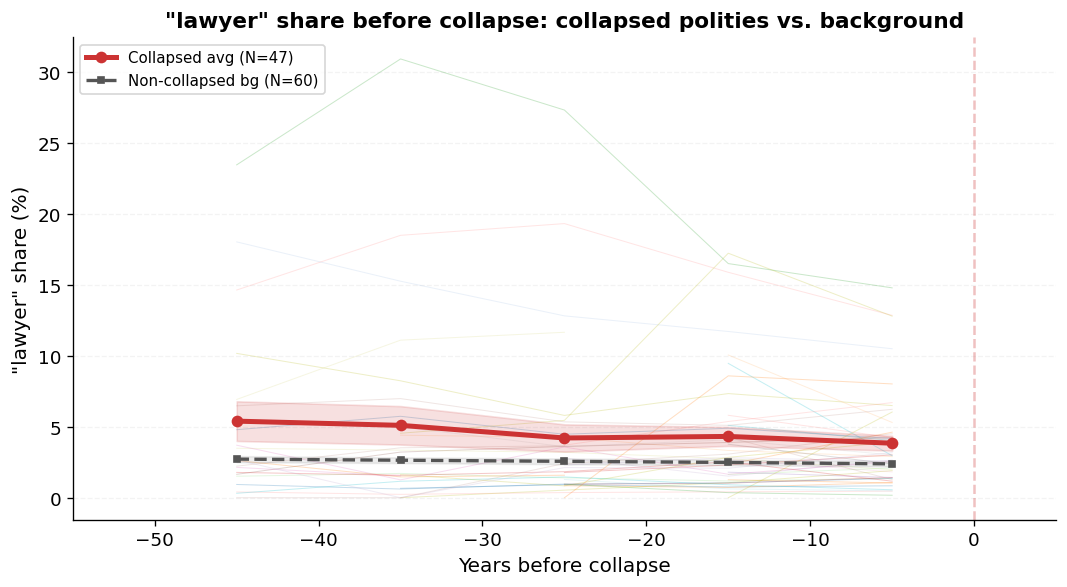

In [5]:
top_occ = results_ctrl[0]['occupation'] if results_ctrl else results[0]['occupation']
print(f'Top signal: "{top_occ}"')

fig, ax = plt.subplots(figsize=(9, 5))
bin_w = 10
cmap = plt.cm.tab20

# ── Collapsed polity curves ──
c_curves = []
for i, (pname, collapse_yr, dur, ptype, nw) in enumerate(polities):
    if occ_per_polity[pname].get(top_occ, 0) < 10:
        continue
    entries = polity_data[pname]
    occ_by_b = defaultdict(int)
    tot_by_b = defaultdict(int)
    for year, occs in entries:
        t_rel = year - collapse_yr
        if t_rel < -50 or t_rel > 0: continue
        b = -bin_w if t_rel == 0 else max((t_rel // bin_w) * bin_w, -50)
        x = b + bin_w / 2
        tot_by_b[x] += 1
        if top_occ in occs: occ_by_b[x] += 1
    curve = [(x, occ_by_b[x] / tot_by_b[x] * 100)
             for x in sorted(tot_by_b) if tot_by_b[x] >= 5]
    if len(curve) >= 2:
        xs, vs = zip(*curve)
        ax.plot(xs, vs, '-', color=cmap(i % 20), lw=0.6, alpha=0.25)
        c_curves.append((list(xs), list(vs)))

# ── Background curves ──
b_curves = []
for w, bg in bg_data.items():
    bd = bg['bin_10']
    curve = [(x, bd[x].get(top_occ, 0) / bd[x]['_total'] * 100)
             for x in sorted(bd) if bd[x]['_total'] >= 5 and bd[x].get(top_occ, 0) >= 1]
    if len(curve) >= 2:
        xs, vs = zip(*curve)
        b_curves.append((list(xs), list(vs)))

# ── Averages ──
def avg_sem(curves_list, all_xs, min_n=3):
    if not curves_list: return None, None, None
    mat = []
    for xs, vs in curves_list:
        d = dict(zip(xs, vs))
        mat.append([d.get(x, np.nan) for x in all_xs])
    arr = np.array(mat)
    nv = np.sum(~np.isnan(arr), axis=0)
    mask = nv >= min_n
    mean = np.nanmean(arr, axis=0)
    sem  = np.nanstd(arr, axis=0) / np.sqrt(np.where(nv > 0, nv, 1))
    return mean, sem, mask

all_xs = sorted(set(x for xs, _ in c_curves + b_curves for x in xs))
if all_xs:
    cm, cs, cmask = avg_sem(c_curves, all_xs)
    if cm is not None and cmask.any():
        xc = np.array(all_xs)[cmask]
        ax.plot(xc, cm[cmask], '-o', color='#cc3333', lw=3, ms=6,
                label=f'Collapsed avg (N={len(c_curves)})', zorder=10)
        ax.fill_between(xc, cm[cmask]-cs[cmask], cm[cmask]+cs[cmask],
                        color='#cc3333', alpha=0.15, zorder=9)
    bm, bs, bmask = avg_sem(b_curves, all_xs)
    if bm is not None and bmask.any():
        xb = np.array(all_xs)[bmask]
        ax.plot(xb, bm[bmask], '--s', color='#555555', lw=2, ms=4,
                label=f'Non-collapsed bg (N={len(b_curves)})', zorder=8)
        ax.fill_between(xb, bm[bmask]-bs[bmask], bm[bmask]+bs[bmask],
                        color='#555555', alpha=0.1, zorder=7)

ax.axvline(0, color='#cc3333', ls='--', lw=1.5, alpha=0.3)
ax.set_xlim(-55, 5)
ax.set_xlabel('Years before collapse', fontsize=12)
ax.set_ylabel(f'"{top_occ}" share (%)', fontsize=12)
ax.set_title(f'"{top_occ}" share before collapse: collapsed polities vs. background',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, frameon=True, edgecolor='#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, ls='--')
plt.tight_layout()
plt.show()

## 5. Judge Control

Check whether "judge" shows a similar collapse signal. If the effect is specific to "lawyer", judges should not show a significant rise.

In [6]:
for occ_check in ['judge']:
    raw = next((r for r in results if r['occupation'] == occ_check), None)
    ctrl = next((r for r in results_ctrl if r['occupation'] == occ_check), None)
    print(f'=== "{occ_check}" ===')
    if raw:
        print(f'  Raw:  {raw["direction"]:4s}  delta={raw["mean_delta"]:+.2f}pp  '
              f'p_adj={raw["pvalue_corrected"]:.4f}  N={raw["n_polities"]}')
    else:
        print(f'  Raw:  not testable (insufficient data)')
    if ctrl:
        print(f'  Ctrl: {ctrl["direction"]:4s}  delta={ctrl["mean_delta"]:+.2f}pp  '
              f'p_adj={ctrl["pvalue_corrected"]:.4f}  N={ctrl["n_polities"]}')
    else:
        print(f'  Ctrl: not testable (insufficient data)')

=== "judge" ===
  Raw:  RISE  delta=+0.10pp  p_adj=0.8733  N=25
  Ctrl: RISE  delta=+0.22pp  p_adj=0.9312  N=25
